In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras import layers, models, losses
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras import layers, models, losses
import tensorflow as tf

class AntipodalConstraint(tf.keras.constraints.Constraint):
    def __call__(self, w):
        return tf.sign(w)  # Forces weights to -1 or 1

class MFFSE_MODIFIED:
  def __init__(self,n,SR):
    self.n = n # Signal dimension (input)
    self.SR = SR # Sensing Rate
    self.model = self.build_model()

  def build_model(self):
    #Input and compression
    input = layers.Input(shape=(self.n,1))
    x = layers.Reshape((self.n,))(input)
    m = int(np.floor(self.n*self.SR))
    x = layers.Dense(
        units=m,   # Example output size
        input_dim=self.n, # Example input size
        activation='linear',
        use_bias=False,
        kernel_initializer='random_uniform',  # Initialize randomly
        kernel_constraint=AntipodalConstraint()  # Apply constraint during forward pass
        )(x)
    x = layers.Reshape((4,int(m/4)))(x)

    #Rising dimensionality and reshaping, Initial Reconstruction
    x = layers.Conv1D(filters=64, kernel_size=3, strides=1, padding="same", use_bias=False,activation='leaky_relu')(x)
    x = layers.Reshape((256,1))(x)

    #Secondary Reconstruction
    first_seq_conv_layer = layers.Conv1D(filters=16, kernel_size=11, padding="same", use_bias=True, activation='leaky_relu')(x)
    second_seq_conv_layer = layers.Conv1D(filters=16, kernel_size=11, padding="same", use_bias=True, activation='leaky_relu')(first_seq_conv_layer)

    first_1x9= layers.Conv1D(filters=16, kernel_size=9, strides=1, padding="same", use_bias=True, activation='leaky_relu')(first_seq_conv_layer)
    first_1x11= layers.Conv1D(filters=16, kernel_size=11, strides=1, padding="same", use_bias=True, activation='leaky_relu')(first_seq_conv_layer)
    first_1x13= layers.Conv1D(filters=16, kernel_size=13, strides=1, padding="same", use_bias=True, activation='leaky_relu')(first_seq_conv_layer)

    second_1x9= layers.Conv1D(filters=16, kernel_size=9, strides=1, padding="same", use_bias=True, activation='leaky_relu')(second_seq_conv_layer)
    second_1x11= layers.Conv1D(filters=16, kernel_size=11, strides=1, padding="same", use_bias=True, activation='leaky_relu')(second_seq_conv_layer)
    second_1x13= layers.Conv1D(filters=16, kernel_size=13, strides=1, padding="same", use_bias=True, activation='leaky_relu')(second_seq_conv_layer)

    add_1x9 = layers.Add()([first_1x9,second_1x9])
    add_1x11 = layers.Add()([first_1x11,second_1x11])
    add_1x13 = layers.Add()([first_1x13,second_1x13])

    concate_layer = layers.Concatenate()([add_1x9,add_1x11,add_1x13]) #shape 1x256x48

    #SE Block
    gap = layers.GlobalAveragePooling1D(keepdims=True)(concate_layer)
    #gap = layers.Reshape((1,12))(gap)
    full_conn_1 = layers.Dense(16)(gap)
    Relu = layers.ReLU()(full_conn_1)
    full_conn_2 = layers.Dense(48)(Relu)
    Sigmoid = layers.Activation('sigmoid')(full_conn_2)
    SE_output = layers.Multiply()([concate_layer, Sigmoid])

    #Conv - lstm - final
    conv_after_se = layers.Conv1D(filters=1, kernel_size=11, padding="same", use_bias=True, activation='leaky_relu')(SE_output)
    lstm = layers.LSTM(units=250)(conv_after_se)
    last_full_connect = layers.Dense((256), activation='relu')(lstm)
    output = layers.Reshape((256,1))(last_full_connect)
    model = tf.keras.Model(inputs=input, outputs=output)
    #model.summary()
    return model

  def train(self,x_train,validation = None, batch_size = 32, epochs=1):
    self.model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005,beta_1=0.9, beta_2=0.999), loss='mse')
    self.model.fit(x_train,batch_size=batch_size,epochs=epochs, validation_data = validation)


In [ ]:
# Download a sample record from the MIT-BIH Arrhythmia Database
#wfdb.dl_database('mitdb', dl_dir='mitdb/', records=["100","101","103","105","106"]);

#increase set
wfdb.dl_database('mitdb', dl_dir='mitdb/', records=["100","101","103","105","106"]);

# Load the ECG signal
record_name = ["100","101","103","105","106"]
record = list()
for i in range(5):
  record.append(wfdb.rdrecord(f'mitdb/{record_name[i]}').p_signal[:,0])
record = np.concatenate(record)
point_length = record.shape[0]
n = 256
n_of_array = int(point_length/n)

# Load signal into x_train
x_train= np.empty((n_of_array,n))
for i in range(n_of_array):
  x_train[i,:] = record[i*n:i*n+n]


#normalization of x_train
x_train_norm=np.zeros(shape=x_train.shape)
for i in range(x_train.shape[0]):
  x_train_norm[i,:] = (x_train[i,:] - np.min(x_train[i,:])) / (np.max(x_train[i,:]) - np.min(x_train[i,:]))

total_size = len(x_train_norm)
train_size = int(total_size * 0.8)
dataset = tf.data.Dataset.from_tensor_slices((x_train_norm,x_train_norm))
dataset = dataset.shuffle(total_size,reshuffle_each_iteration=False)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)


In [ ]:
#UBAH disini SR nya los
MFFSE_mod = MFFSE_MODIFIED(256,0.5)
MFFSE_mod.train(train_ds,val_ds,batch_size=32,epochs=250)

In [ ]:
MFFSE_mod.model.save('SR_05_MFFSE_MOD_Normalized_Train_e250.keras')

DOWNLOAD X TEST

In [ ]:
#generate xtest from database
wfdb.dl_database('mitdb', dl_dir='mitdb/', records=["201","202","203"]);
record_name = ["201","202","203"]

record = list()
for i in range(3):
  record.append(wfdb.rdrecord(f'mitdb/{record_name[i]}').p_signal[:,0])
record = np.concatenate(record)

point_length = record.shape[0]
n = 256
n_of_array = int(point_length/n)

# Load signal into x_test
x_test= np.empty((n_of_array,n))
for i in range(n_of_array):
  x_test[i,:] = record[i*n:i*n+n]

x_test_norm = np.empty((n_of_array,n))
for i in range(n_of_array):
  x_test_norm[i] = (x_test[i] - np.min(x_test[i]))/(np.max(x_test[i])-np.min(x_test[i]))


Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating list of all files for: 201
Generating list of all files for: 202
Generating list of all files for: 203
Finished downloading files


In [ ]:
#Ambil 1000 sample data random dari x_test_norm
#Dan hitung prd dan SNR avg
random_pick_norm = x_test_norm[np.random.choice(x_test_norm.shape[0], size=1000, replace=False)]
out_rand_norm = MFFSE_mod.model.predict(random_pick_norm)

#Calculate AVG PRD and AVG SNR from random picked sample
PRD_list = list()
SNR_list = list()

for i in range(1000):
  PRD_list.append(np.linalg.norm(random_pick_norm[i]-out_rand_norm[i,:,0], ord=2)/np.linalg.norm(random_pick_norm[i], ord=2)*100)
  SNR_list.append(10 * np.log10(np.linalg.norm(random_pick_norm[i],2)**2/np.linalg.norm(random_pick_norm[i]-out_rand_norm[i,:,0],2)**2))

print('PRD = ', np.average(PRD_list))
print('SNR = ', np.average(SNR_list))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
PRD =  15.261654119211403
SNR =  16.820063619665518


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


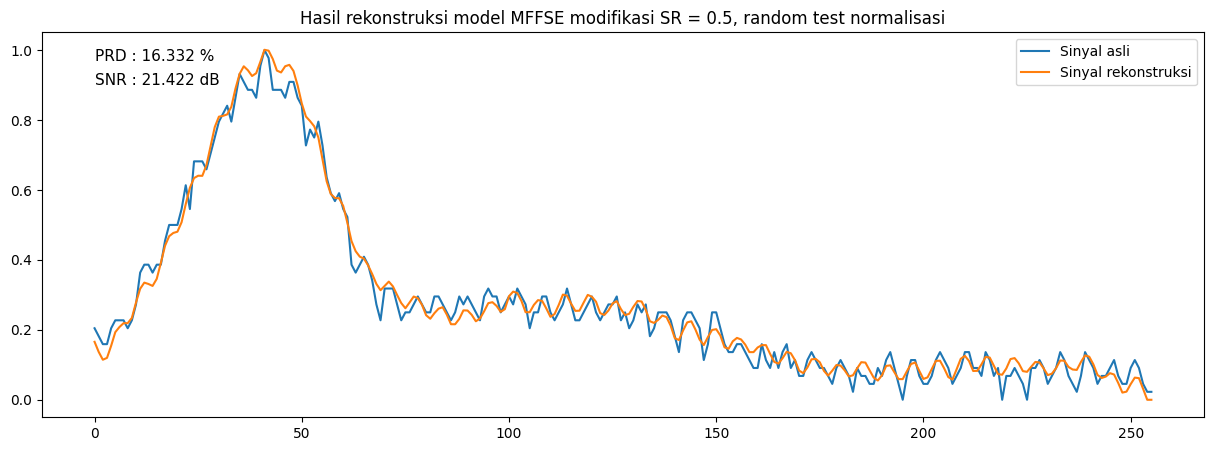

In [ ]:
#Plotting sample random yg ada di random_pick_norm
l = 500
ss = MFFSE_mod.model.predict(random_pick_norm[l:l+1])
plt.figure(figsize=(15,5))
plt.title("Hasil rekonstruksi model MFFSE modifikasi SR = 0.5, random test normalisasi")
plt.plot(random_pick_norm[l], label="Sinyal asli")
plt.plot(ss[0,:,0], label="Sinyal rekonstruksi")
plt.legend()
prd = np.linalg.norm(random_pick_norm[l]-ss[0,:,0], ord=2)/np.linalg.norm(x_train_norm[l], ord=2)*100
snr = 10 * np.log10(np.linalg.norm(random_pick_norm[l],2)**2/np.linalg.norm(random_pick_norm[l]-ss[0,:,0],2)**2)
plt.text(0,0.97,f"PRD : {prd:.3f} %", fontsize = 11)
plt.text(0,0.9,f"SNR : {snr:.3f} dB", fontsize = 11)
plt.show()


Dibawah untuk pengujian random dari x_train_norm dan dapat nilai PRD dan SNR avg

In [ ]:
#Random shuffle array dari x_train_norm
#Ambil 1000 sample random dan prediksi
random_pick = x_train_norm[np.random.choice(x_train_norm.shape[0], size=1000, replace=False)]
#plt.plot(random_pick[0])
out_rand = MFFSE_mod.model.predict(random_pick)

#Calculate AVG PRD and AVG SNR from random picked sample
PRD_list = list()
SNR_list = list()

for i in range(1000):
  PRD_list.append(np.linalg.norm(random_pick[i]-out_rand[i,:,0], ord=2)/np.linalg.norm(random_pick[i], ord=2)*100)
  SNR_list.append(10 * np.log10(np.linalg.norm(random_pick[i],2)**2/np.linalg.norm(random_pick[i]-out_rand[i,:,0],2)**2))

print('PRD = ', np.average(PRD_list))
print('SNR = ', np.average(SNR_list))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
PRD =  7.600466871588145
SNR =  22.666005971449717
